In [2]:
import numpy as np
import time
import yaml
import h5py # https://docs.h5py.org/en/stable/quick.html to read hdf5 files
import matplotlib.pyplot as plt
import importlib
import helpers
importlib.reload(helpers)

<module 'helpers' from '/cluster/medbow/gscratch/ajense28/GK/Si-VASP/helpers.py'>

# HEAT CAPACITY [J/K/mol]
$$ C_v=\frac{dU}{dT} $$


## Einstein Model
$$ C_v=\iiint_V \sum_s k_B (\frac{h f}{k_B T})^2 \frac{e^{\frac{h f}{k_B T}}}{(e^{\frac{h f}{k_B T}}-1)^2} \frac{N_A}{n} dq^3 $$

In [3]:
def compute_einstein_heat_capacity(freq,temp):
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    n=len(freq[:,0]) # number of mesh values sampled
    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    cv=np.zeros(len(temp)) # initialize
    for i,T in enumerate(temp) if not isinstance(temp,int) else (0,temp):
        if T > 0:
            for f in np.split(freq,indices_or_sections=len(freq[:,0]),axis=0):
                x=(h*f)/(kB*T)#np.where(T > 0,(h*f)/(kB*T),np.nan)
                cv[i] = cv[i] + np.sum(kB*np.power(x,2)*(np.exp(x))/np.power(np.exp(x)-1,2))# returned in units of J/K/point
    return cv*NA/n #*NA/n # units of J/K/mol
# COMPUTE THE EINSTEIN HEAT CAPACITY, retain individual values for modes (no summation)
def compute_einstein_mode_heat_capacity(freq,temp,weights):
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    n=len(freq[:,0]) # number of mesh values sampled
    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    cv=np.zeros([len(temp),len(freq[0,:])]) # initialize
    for i,T in enumerate(temp) if not isinstance(temp,int) else (0,temp):
        if T > 0:
            for s,f in enumerate(np.split(freq,indices_or_sections=len(freq[0,:]),axis=1)): # do each mode separately (should repeat num_mode times)
                # f_weighted=(f.T*weights).flatten(); # frequency weighted by qpoint to account for mesh symmetry NOT ACCURATE TO CV REF VALUES
                x=(h*f)/(kB*T) 
                cv[i,s] = np.sum(kB*np.power(x,2)*(np.exp(x))/np.power(np.exp(x)-1,2))# returned in units of J/K/point
    return cv # units of J/K

## Debye Model
$$ C_v=9Nk_B(\frac{T}{T_D})^3 \int^{x_D}_0 \frac{x^4 e^x}{(e^x-1)^2}dx $$
$$ x = \frac{h f}{k_B T} ; x_D = \frac{T_D}{T} $$

In [4]:
def compute_debye_heat_capacity(freq,temp):
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    N=len(freq[0,:])/3 # num phonon modes = num 'modes' / 3 polarizations = 2
    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    # Wikipedia says 645K Debye temperature for silicon crystal
    TD=495 
    cv=np.zeros(len(temp))
    # assumes temperatures are sorted low to high in numerical order for simplicity
    for i,T in enumerate(temp):
        if T>0:
            xD=TD/T # unitless Debye limit
            for f in np.split(freq,indices_or_sections=len(freq[:,0]),axis=0): # integrate each qpoint separately
                x=(h*f)/(kB*T) # this num modes*1 matrix of x values for a particular qpt and T 
                xval=x[np.logical_and(0<=x,x<=xD)] # all x values within the integral limit for a particular mode
                cv[i]=cv[i] + 9*N*kB*np.power(xD,-3) * np.trapz(np.power(xval,4)*np.exp(xval)/np.power(np.exp(xval)-1,2),x=xval)
                # CHECK THE CUBED VALUE BEFORE TRAPEZOIDAL
                # check literature for debye temp for dft phonon calc ***
    return cv*NA/len(freq[:,0]) # units of J/molK

In [5]:
def dulong_petit_limit(freq,temp): 
    kB=1.380649e-23 # [J/K]
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    N=1 #len(freq[0,:])/3 # number of primitive cells / number of modes
    dulong_petit_result=3*N*kB # theoretical upper limit for cv
    #print(dulong_petit_result) # = 49.886775708919444 [2*J/K/mol]
    # returns the dulong petit result as a horizontal line (T,cv) to compare to other results
    cv=dulong_petit_result*np.ones(len(temp))
    return cv*NA # units of J/molK

In [6]:
# Visualize heat capacity
import matplotlib.pyplot as plt
import numpy as np
def plot_heat_capacity(xvals,yvals,labels,show=True,save=False,savefile=None,xlabel=f'Temperature (K)',ylabel=f'$C_v$ (J/K/mol)',title='Thermal Property Comparison Plot',xlim=[0,2000],ylim=None,sz=[8,4],style=['-',':','--','-.', ':','--','-.', ':']):
    [symbols,colors] = helpers.plot_settings()

    fig = plt.figure(figsize=(sz))
    for i,data in enumerate(zip(*yvals)):
        plt.plot(xvals,data,color=colors[i%24],label=labels[i],ls=style[i%8],lw=2.5)
    
    # Labels and styling
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.xlabel(xlabel, labelpad=10)
    plt.ylabel(ylabel, labelpad=10)
    plt.title(title, pad=20)
    plt.legend()
    # Grid styling
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    if show:
        plt.show()
    if save:
        fig.savefig(savefile, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {savefile}")

In [7]:
# Heat Capacity read in values
import numpy as np
import importlib
import helpers
importlib.reload(helpers)

inputfile='888_nosym_phonopy.yaml' #'202020_0-2000K'
read_new=True
try:
    # REFERENCE VALUES
    refdata=helpers.get_thermal_properties_refdata('./data-bin/thermal_properties_'+inputfile) 
    ref_phonopy_cv=refdata.ref_heat_capacity
    # INPUT VALUES
    data=helpers.get_data_yaml('./data-bin/mesh_'+inputfile)
    temperatures=refdata.temperature # USE REFERENCE TEMPERATURE VALUES
    frequencies=data.frequency
    print(np.shape(temperatures))
    print(np.shape(frequencies))
    print(np.shape(ref_phonopy_cv))
except Exception as e:
    print(e)


(101,)
(512, 6)
(101,)


(512, 6)



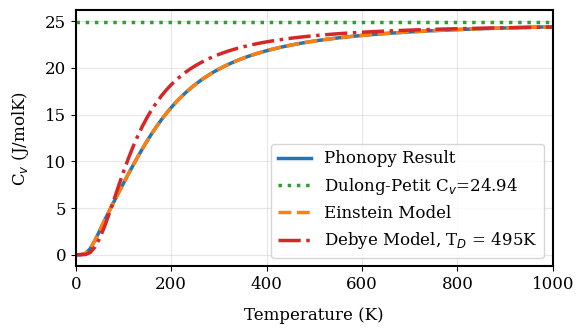

In [8]:
# Heat Capacity Calculation & Analysis
NA=6.02214076e23 # units:[atom/mol] # avogadro's number
# theoretical upper limit value
print(frequencies.shape)
ref_dulong_petit=dulong_petit_limit(freq=frequencies,temp=temperatures)
# CALCULATE HEAT CAPACITY Cv
calc_einstein_cv=compute_einstein_heat_capacity(freq=frequencies,temp=temperatures)
calc_debye_cv=compute_debye_heat_capacity(freq=frequencies,temp=temperatures)
print()
# labels as an array of strings
labels=['Phonopy Result','Dulong-Petit C$_v$=24.94','Einstein Model', 'Debye Model, T$_D$ = 495K']
# Zip the values then unzip them inside the function
heat_capacity_vals=zip(ref_phonopy_cv/2,ref_dulong_petit,calc_einstein_cv/2,calc_debye_cv)

ylabel='C$_v$ (J/molK)'
title='Phonon Heat Capacity of Silicon'
temp_limit=[0,1000]
cv_limit=None
size=[6,3.5]
plot_heat_capacity(xvals=temperatures,yvals=heat_capacity_vals,labels=labels,show=True,save=False,ylabel=ylabel,title=None,xlim=temp_limit,ylim=cv_limit,sz=size)

# ENTROPY [J/K/mol]
$$ S = \frac{1}{2T} \sum_{q,\nu} h f coth\left(\frac{h f}{2k_B T}\right) - k_B \sum_{q,\nu} ln\left(2sinh \left( \frac{h f}{2 k_B T} \right)\right) $$

In [9]:
def compute_entropy(freq,temperatures):
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    n=len(freq[:,0]) # num mesh pts
    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    S=np.zeros(len(temperatures)) # initialize
    i=len(temperatures[temperatures<=0]) # index variable because the loop iterates over T values
    # assumes temperatures are sorted low to high in numerical order for simplicity
    for T in temperatures[temperatures>0]:
        S[i] = 1/(2*T)*np.sum(h*freq/np.tanh(h*freq/(2*kB*T))) - kB*np.sum(np.log(2*np.sinh(h*freq/(2*kB*T))))
        i=i+1
    return S*NA/n # units of J/K/mol

In [10]:
# Entropy read in values
import numpy as np
import importlib
import helpers
importlib.reload(helpers)

inputfile='202020_0-2000K'
try:
    # If data has already been read in
    # ref_phonopy_S=refdata.entropy
    temperatures=refdata.temperature # USE REFERENCE TEMPERATURE VALUES
    frequencies=data.frequency
except Exception:
    # REFERENCE VALUES
    refdata=helpers.get_refdata(inputfile)
    # ref_phonopy_S=refdata.get_entropy()
    # INPUT VALUES
    data=helpers.get_data_yaml(yamlfile='./data-bin/phonopy_'+inputfile+'_mesh.yaml') # check inputfile variable above ref value read-in
    temperatures=refdata.get_temperature() # USE REFERENCE TEMPERATURE VALUES
    frequencies=data.get_freq()

In [11]:
# Entropy Calculation and Analysis

# calc_s=compute_entropy(freq=frequencies,temperatures=temperatures)

# # add values to a dictionary for the plot function
# key=['Phonopy Result','Calculated Entropy']
# temperature_vals={key[0]:temperatures}
# temperature_vals.update({key[1]:temperatures})
# entropy_vals={key[0]:ref_phonopy_S}
# entropy_vals.update({key[1]:calc_s})

# ylabel='S (J/K/mol)'
# title='Phonon Entropy of Silicon'
# temp_limit=[0,2000]
# size=[7,5]
# plot_thermal_property(temperature_vals,entropy_vals,key,show=True,save=False,ylabel=ylabel,title=title,xlim=temp_limit,sz=size)

# PHONON BAND STRUCTURE AND DENSITY OF STATES

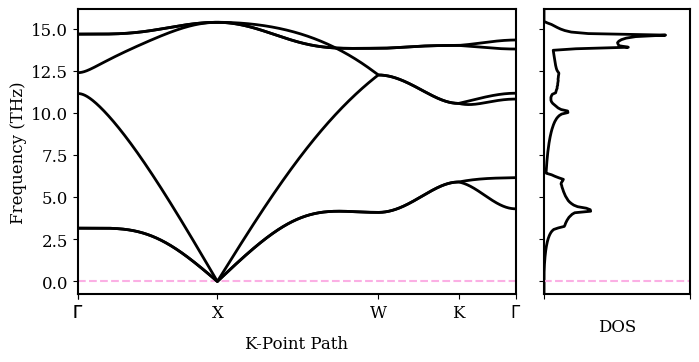

In [12]:
# band structure and density of states plot
import matplotlib.pyplot as plt
import numpy as np
import yaml
def plot_bands_and_dos(dosfile='./data-bin/Si_total_dos.dat',bandsfile='./data-bin/Si_band.yaml',fermi=0,show=True,save=False,savefile=None,xlabel=f'T (K)',ylabel=f'Frequency (Hz)',title='Band Structure and Density of States',xlim=[None,None],ylim=[None,None],sz=[8,6]):
    # import data from files
    try: # DOS
        numeric = np.loadtxt(dosfile, comments='#', dtype=np.float64)
        dos_frequency=numeric[:,0]
        dos=numeric[:,1]
    except Exception as e:
        print(f'Failed to extract total_dos.dat from provided input files, try again. {e}')
        exit

    try: # BANDS
        with open(bandsfile, 'r') as f:
            bandsdata = yaml.safe_load(f)
        distance=np.array([phonon['distance'] for phonon in bandsdata['phonon']])
        bands=np.array([[band['frequency'] for band in phonon['band']] for phonon in bandsdata['phonon']])
        labels= np.array([labels for labels in bandsdata['labels']])
        segment_nqpoint=np.array([n for n in bandsdata['segment_nqpoint']])
    except Exception as e:
        print(f'Failed to extract band.yaml from provided input files, try again. {e}')
        exit
        
    # Set matplotlib parameters for professional appearance
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.linewidth'] = 1.5
    
    fig, axs = plt.subplots(nrows=1, ncols=2,sharey=True,figsize=sz,gridspec_kw={'width_ratios': [3, 1]})
    
    fig.suptitle(title,fontsize=14)

    plt.subplot(121) # BANDS
    
    kpath=np.zeros(len(segment_nqpoint)+1)
    for k in range(0,len(segment_nqpoint)):
        kpath[k+1]=distance[np.sum(segment_nqpoint[:k])]
    #print(kpath)
    # plt.vlines(kpath[1:-1],ylim[0],ylim[1],color=(0.5803921568627451, 0.5803921568627451, 0.5803921568627451),linestyle='dashed')
    plt.hlines(0,kpath[0],kpath[-1],color=(0.984313725490196, 0.6862745098039216, 0.8941176470588236),linestyle='dashed',label='Fermi')
    for b in range(len(bands[0,:])):
        plt.plot(distance, bands[:,b]-(fermi), color='black',lw=2)
    # band labels and styling
    plt.xticks(kpath,np.append(labels[:,0],labels[-1,-1]))#kpoints=['L','\u0393','X','W','K','\u0393']
    plt.xlim([kpath[0],kpath[-1]])
    plt.ylim(ylim)
    plt.xlabel('K-Point Path', labelpad = 10)
    plt.ylabel('Frequency (THz)', labelpad = 3)
    #plt.legend()
    
    # DOS
    plt.subplot(122)
    plt.plot(dos/np.max(dos), dos_frequency-(fermi), color='black',lw=2)
    plt.hlines(0,0,1.5,color=(0.984313725490196, 0.6862745098039216, 0.8941176470588236),linestyle='dashed',label='Fermi')
    plt.xticks([0,1.2],['',''])
    plt.xlabel('DOS',  labelpad = 10)
    plt.xlim(0,1.2)
    plt.ylim(ylim)

    plt.tight_layout()
    if show:
        plt.show()
    if save:
        fig.savefig(savefile, dpi=300, bbox_inches='tight')
        print(f"Saved plot to {savefile}")

    plt.show()
plot_bands_and_dos(dosfile='./data-bin/old/Si_total_dos.dat',bandsfile='./data-bin/old/Si_band.yaml',title=None,sz=[7,4])

# PHONO3PY CALCULATIONS FOR THERMAL CONDUCTIVITY
$$\kappa = \frac{1}{V} \sum_s C_v(s) v(s) \otimes v(s) \tau(s)$$
Outer product of group velocities $v(s) \otimes v(s)$ Get using --gv outer product divided by primitive cell volume V_0 in THz^2/Angstrom
Lifetime $\tau_\lambda = \frac{1}{2\gamma}$

## MODE HEAT CAPACITY

In [13]:
# COMPUTE THE EINSTEIN HEAT CAPACITY, retain individual values for modes (no summation)
def compute_einstein_mode_heat_capacity(freq,temp,weights):
    NA=6.02214076e23 # units:[atom/mol] # avogadro's number
    n=len(freq[:,0]) # number of mesh values sampled
    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    cv=np.zeros([len(temp),len(freq[0,:])]) # initialize
    for i,T in enumerate(temp) if not isinstance(temp,int) else (0,temp):
        if T > 0:
            for s,f in enumerate(np.split(freq,indices_or_sections=len(freq[0,:]),axis=1)): # do each mode separately (should repeat num_mode times)
                # f_weighted=(f.T*weights).flatten(); # frequency weighted by qpoint to account for mesh symmetry NOT ACCURATE TO CV REF VALUES
                x=(h*f)/(kB*T) 
                cv[i,s] = np.sum(kB*np.power(x,2)*(np.exp(x))/np.power(np.exp(x)-1,2))# returned in units of J/K/point
    return cv # units of J/K

In [14]:
# VISUALIZE MODE HEAT CAPACITY VERSUS REFERENCE VALUE
def plot_mode_heat_capacity(calc_mode_heat_capacity,ref_mode_heat_capacity,temperatures,title=None,size=None):
    [symbols, colors] = helpers.plot_settings()
    fig = plt.figure(figsize=size or (6, 3))
    modes=calc_mode_heat_capacity.shape[1]
    for s in range(modes):
        plt.plot(temperatures,ref_mode_heat_capacity[:,s],'-',color=colors[s],label='ref m$_{'+f'{s+1}'+'}$')
    for s in range(modes):
        plt.plot(temperatures,calc_mode_heat_capacity[:,s],'o',color=colors[s],ms=3,label='calc m$_{'+f'{s+1}'+'}$')
    # plt.plot(temperatures,np.sum(ref_mode_heat_capacity,axis=1),'-k',lw=2,label='REF TOT')
    # plt.plot(temperatures,np.sum(calc_mode_heat_capacity,axis=1),'--c',lw=2,label='CALC TOT')
    # plt.xlim((0,400))
    plt.xlabel('Temperature (K)', labelpad=10)
    plt.ylabel('C$_v$ (J/molK)', labelpad=10)
    plt.title(title, pad=20)
    # plt.legend(ncols=4,fontsize=7)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## GROUP VELOCITY OUTER PRODUCT

In [15]:
# COMPUTE GROUP VELOCITY OUTER PRODUCT
def compute_gv_by_gv(gv,weights): # only works for no-symmetry calculations
    gv_by_gv=np.zeros((len(gv[:,0,0]),len(gv[0,:,0]),6)) # qpt
    for q in range(len(gv[:,0,0])): 
        for s in range(len(gv[0,:,0])):
            gv_by_gv[q,s,:]=gv_by_gv[q,s,:]+ [gv[q,s,0]*gv[q,s,0],gv[q,s,1]*gv[q,s,1],gv[q,s,2]*gv[q,s,2],gv[q,s,1]*gv[q,s,2],gv[q,s,0]*gv[q,s,2],gv[q,s,0]*gv[q,s,1]]
        gv_by_gv[q,:,:] = gv_by_gv[q,:,:] * weights[q] # weight the value
    return gv_by_gv

In [16]:
# VISUALIZE GROUP VELOCITY OUTER PRODUCT
def plot_gv_by_gv(gv_by_gv,ref_gv_by_gv=None, sum_over="bands", components=None,ylabel=None, title=None,size=None):
    [symbols, colors] = helpers.plot_settings()
    VOIGT_LABELS = {0: "xx", 1: "yy", 2: "zz", 3: "yz", 4: "xz", 5: "xy"}
    if components is None:
        components = {v: k for k, v in VOIGT_LABELS.items()}

    axis = {"bands": 1, "qpoints": 0}[sum_over]
    data = gv_by_gv.sum(axis=axis)          # (num_qpts, 6) or (num_bands, 6)
    x = np.arange(data.shape[0])
    xlabel = "q-point index" if sum_over == "bands" else "band index"

    fig, ax = plt.subplots(figsize=size or (8, 4))
    for i, (label, idx) in enumerate(components.items()):
        ax.plot(x, data[:, idx], label=label, color=colors[i % len(colors)], linewidth=0.1, marker=symbols[i % len(symbols)])
    if ref_gv_by_gv is not None:
        refdata=ref_gv_by_gv.sum(axis=axis)
        for j, (label, idx) in enumerate(components.items()):
            ax.plot(x, refdata[:, idx], label='ref'+label, color=colors[i+j+1 % len(colors)], linewidth=0.1, marker=symbols[i+j+1 % len(symbols)],linestyle=':')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel or r"$\sum\, v_\alpha v_\beta$")
    ax.set_title(title)# or f"gv⊗gv summed over {sum_over}"
    ax.legend(frameon=True, framealpha=0.7, edgecolor="black",fontsize=9,loc=(1,0))
    fig.tight_layout()
    fig.show()

## RELATIVE ERROR FORMULATION
$$E = \frac{|ref - calc|}{|ref|}$$

In [189]:
# RELATIVE ERROR FORMULATION CALCULATION AND VISUALIZATION FUNCTIONS
def compute_relative_error(calcdata,refdata):
    numerator = abs(refdata - calcdata)
    denom = np.where(refdata != 0, abs(refdata), abs(calcdata))
    error = np.where(denom != 0, numerator / denom, 0.0)
    print(f'max error = {np.nanmax(error)}')
    return error

def plot_relative_error(error, xlabel="X-Axis", title="Relative Error", components=None,size=None,xval=None):
    [symbols, colors] = helpers.plot_settings()
    x = np.arange(error.shape[0]) if xval is None else xval
    is_modes = False
    fig, ax = plt.subplots(figsize=size or (8, 4))
    if np.nanmax(error) > 10:
        plt.yscale('log')
    else:
        plt.yscale('linear')
    if len(np.shape(error)) > 1: # obviously don't iterate if there is only one set of data
        VOIGT_LABELS = {0: "xx", 1: "yy", 2: "zz", 3: "yz", 4: "xz", 5: "xy"}
        is_modes = error.shape[1] > 6 # check if data is modes or voigt xyz
        if components is None and not is_modes:
            index = list(VOIGT_LABELS.keys())
            label = list(VOIGT_LABELS.values())
        elif components is None and is_modes:
            index = np.arange(error.shape[1])
            label = [f'mode {idx+1}' for idx in index]
        elif not isinstance(components, int):
            index = components
            label = [f'mode {idx+1}' for idx in components] if is_modes else [VOIGT_LABELS[idx] for idx in components]
        else:
            index = components
            label = f'mode {components}' if is_modes else VOIGT_LABELS[components]
        for i, l, idx in zip(index,label,index) if not isinstance(index,int) else zip(index,label,index):
            ax.plot(x, error[:, idx], label=l, color=colors[i % len(colors)], linewidth=0.1, marker=symbols[i % len(symbols)])
        ax.plot(x, np.sum(error,axis=1), label='total error', color='k', linewidth=1, marker='|')
    else:
        ax.plot(x, error, label='total error', color='k', linewidth=1, marker='|')
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"Error")
    ax.set_title(title)
    ax.legend(frameon=True, framealpha=0.7, edgecolor="black",fontsize=9,ncols = 1 if not is_modes else 2, loc='best' if not is_modes else (1,0))
    fig.tight_layout()
    plt.show()


## THERMAL CONDUCTIVITY
$$\kappa = \frac{1}{V} \sum_s C_v(s) v(s) \otimes v(s) \tau(s) = \frac{1}{V} \sum_s \frac{C_v(s) v(s) \otimes v(s)}{ (2*\Gamma) }$$


In [ ]:
# COMPUTE THERMAL CONDUCTIVITY 
def compute_kappa(freq,temp,gv,gamma,kappa_unit_conversion):
    # note that temp values must match the reference temperatures for accuracy with gamma -> alter results
    if isinstance(temp,int): temp = np.append(np.nan,temp)
    N_temp=temp.shape[0]
    N_qpoints=freq.shape[0]    
    N_modes=freq.shape[1]

    h=6.62607015e-34 # [J/Hz]  
    kB=1.380649e-23 # [J/K]
    eV2J=1.602177e-19 # 1 eV / 1.602177e-19 J

    #  eV/molK -----------------------------------
    cv=np.zeros([N_temp,N_qpoints,N_modes]) # initialize C_v
    for i,T in enumerate(temp) if not isinstance(temp,int) else (0,temp):
        if T > 0:
            for s,f in enumerate(np.split(freq,indices_or_sections=len(freq[0,:]),axis=1)): # do each mode separately (should repeat num_mode times)
                x=(h*f)/(kB*T) 
                cv[i,:,s] = (kB*np.power(x,2)*(np.exp(x))/np.power(np.exp(x)-1,2)).flatten() # returned in units of J/K/point
    cv=cv/eV2J # need to be in eV units
    # gv_by_gv units Hz^2 * A^2 -----------------------------------
    gv_by_gv=np.zeros((N_qpoints,N_modes,6)) # qpt
    for q in range(N_qpoints): 
        for s in range(N_modes):
            gv_by_gv[q,s,:]=gv_by_gv[q,s,:]+ [gv[q,s,0]*gv[q,s,0],gv[q,s,1]*gv[q,s,1],gv[q,s,2]*gv[q,s,2],gv[q,s,1]*gv[q,s,2],gv[q,s,0]*gv[q,s,2],gv[q,s,0]*gv[q,s,1]]

    # kappa units W/mK
    mode_kappa = np.empty([N_temp,N_qpoints,N_modes,6])
    tau = np.where(np.where(gamma > 0, gamma, -1) > 0, 1.0 / (2 * np.where(gamma > 0, gamma, -1)), 0)
    for x in range(len(gv_by_gv[0,0,:])):
        mode_kappa[:,:,:,x] =  tau * cv * gv_by_gv[:,:,x] * kappa_unit_conversion * 1e-12 # unit correction for Hz
    kappa = mode_kappa.sum(axis=1).sum(axis=1)
    return mode_kappa



In [198]:
# VISUALIZE THERMAL CONDUCTIVITY, summed over bands or qpoints against temperature
def plot_kappa(calc_kappa,ref_kappa=None,sum_over='bands',title=None, components=None,temperatures=None,size=None):
    [symbols, colors] = helpers.plot_settings()
    VOIGT_LABELS = {0: "xx", 1: "yy", 2: "zz", 3: "yz", 4: "xz", 5: "xy"}
    if components is None:
        index = [idx for idx, label in VOIGT_LABELS.items()]
        label = [label for idx, label in VOIGT_LABELS.items()]
    elif not isinstance(components, int):
        index = components
        label = [VOIGT_LABELS[idx] for idx in components]
    else:
        index = components
        label = VOIGT_LABELS[components]

    fig, ax = plt.subplots(figsize=size or (8, 4))
    if len(calc_kappa.shape) == 3:
        axis = {"qpoints": 0,"bands": 1}[sum_over]
        data = calc_kappa.sum(axis=axis)          # (num_qpts, 6) or (num_bands, 6)
        x = np.arange(data.shape[0])
        xlabel = "q-point index" if sum_over == "bands" else "band index"

        for i, l, idx in zip(index,label,index) if not isinstance(index,int) else zip(index,label,index):
            ax.plot(x, data[:, idx], label=l, color=colors[i % len(colors)], linewidth=1, marker=symbols[i % len(symbols)],markersize=3)
        if ref_kappa is not None:
            ref_kappa=ref_kappa.sum(axis=axis)
            for j, l, idx in zip(index,label,index) if not isinstance(index,int) else zip(index,label,index):
                ax.plot(x, ref_kappa[:, idx], label='ref '+l, color=colors[i+j+1 % len(colors)], linewidth=1, marker=symbols[i+j+1 % len(symbols)],markersize=3,linestyle=':')
        plt.yscale('linear')
    else:
        x = 10*np.arange(calc_kappa.shape[0]) if temperatures is None else temperatures
        xlabel = "Temperature (K)"
        sum_over = "bands and qpoints"
        if len(calc_kappa.shape) == 4:
            calc_kappa = calc_kappa.sum(axis=2).sum(axis=1)
        for i, l, idx in zip(index,label,index) if not isinstance(index,int) else zip(index,label,index):
            ax.plot(x, calc_kappa[:, idx]/3, label=l, color=colors[i % len(colors)], linewidth=1, marker=symbols[i % len(symbols)],markersize=3)
        if ref_kappa is not None:
            if len(ref_kappa.shape) == 4:
                ref_kappa = ref_kappa.sum(axis=2).sum(axis=1)
            for j, l, idx in zip(index,label,index) if not isinstance(index,int) else zip(index,label,index):
                ax.plot(x, ref_kappa[:, idx], label='ref '+l, color=colors[i+j+1 % len(colors)], linewidth=1, marker=symbols[i+j+1 % len(symbols)],markersize=3,linestyle=':')
        # plt.xscale('linear')
        plt.yscale('linear')
        
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"K W/mK")
    ax.set_title(title)
    ax.legend(frameon=True, framealpha=0.7, edgecolor="black",fontsize=9,loc=(1,0))
    fig.tight_layout()
    fig.show()


# plot_kappa(calc_kappa=calc_kappa,ref_kappa=ref_mode_kappa,sum_over="qpoints",title=None,size=sz)


In [ ]:
# GET VALUES
import numpy as np
import h5py # https://docs.h5py.org/en/stable/quick.html to read hdf5 files
import matplotlib.pyplot as plt
import importlib
import helpers
importlib.reload(helpers)

inputfile='./data-bin/kappa_555_nosym_phono3py.hdf5'
try:
    data = helpers.get_data_hdf5(inputfile=inputfile)
    weights=data.qpoint_weight
    gv = data.group_velocity
    freq=data.frequency
    temperatures=data.temperature
    gamma = data.gamma
    kappa_unit_conversion=data.kappa_unit_conversion
    # reference values
    ref_gv_by_gv = data.gv_by_gv
    ref_mode_heat_capacity=np.sum(data.heat_capacity,axis=1)#*1.6022E-19 # CONVERT TO J/K
    ref_mode_kappa = data.ref_mode_kappa
    ref_kappa = data.ref_thermal_conductivity
except Exception as e:
    print(f'Failed to load data because of {e}')
# print(gv)


In [78]:
# RUN CALCULATION
try:
    calc_mode_heat_capacity=compute_einstein_mode_heat_capacity(freq=freq,temp=temperatures,weights=weights)
    calc_gv_by_gv = compute_gv_by_gv(gv=gv,weights=weights)
    calc_kappa=compute_mode_kappa(Cv=calc_mode_heat_capacity,gv_by_gv=calc_gv_by_gv,kappa_unit_conversion=kappa_unit_conversion,gamma=gamma*1e-12)
    # print(weights)
except Exception as e:
    print(f'Failed to compute because of {e}')

No temperatures chosen, doing all of them (likely 0-1000K step 10).



0.9999997181695183
max error = 0.43664494083856253
max error = 0.44519439993799764
max error = 0.42894770159338214


<>:9: SyntaxWarning: invalid escape sequence '\k'
<>:10: SyntaxWarning: invalid escape sequence '\k'
<>:9: SyntaxWarning: invalid escape sequence '\k'
<>:10: SyntaxWarning: invalid escape sequence '\k'
/tmp/ipykernel_3201979/3181231109.py:9: SyntaxWarning: invalid escape sequence '\k'
  ax.plot(x, calc_kappa[:], label='Si $\kappa_x$ (DFT)', color=colors[0 % len(colors)], linewidth=3, marker=symbols[0 % len(symbols)],markersize=0)
/tmp/ipykernel_3201979/3181231109.py:10: SyntaxWarning: invalid escape sequence '\k'
  ax.plot(x, ref_kappa[:], label='Si $\kappa_x$ Ref', color=colors[3 % len(colors)], linewidth=3, marker=symbols[1 % len(symbols)],markersize=1,linestyle=':')
/tmp/ipykernel_3201979/3147354955.py:5: RuntimeWarning: invalid value encountered in divide
  error = np.where(denom != 0, numerator / denom, 0.0)


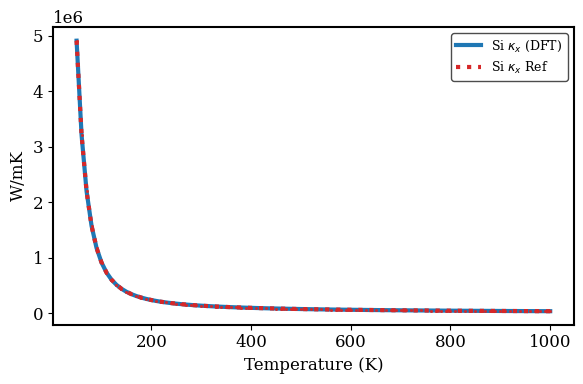

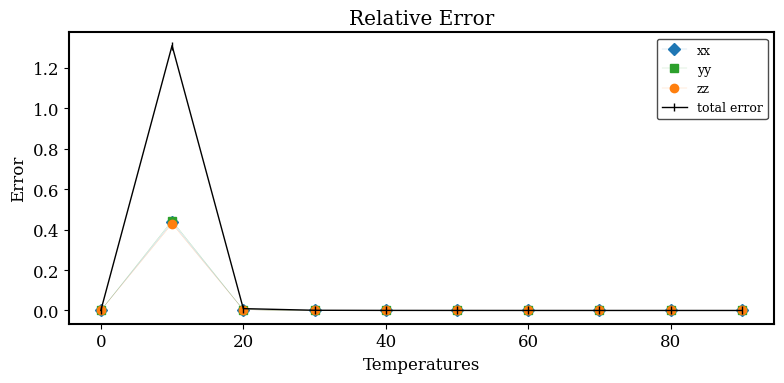

In [ ]:
# VISUALIZE RESULTS
print()

         
def plot_tc(calc_kappa,ref_kappa,temperatures=None,title=None,size=None,xlabel="Temperature (K)",ylabel=r"K W/mK"):
    [symbols, colors] = helpers.plot_settings()
    fig, ax = plt.subplots(figsize=size or (8, 4))
    x = 10*np.arange(calc_kappa.shape[0]) if temperatures is None else temperatures
    ax.plot(x, calc_kappa[:], label=r'Si $\kappa_x$ (DFT)', color=colors[0 % len(colors)], linewidth=3, marker=symbols[0 % len(symbols)],markersize=0)
    ax.plot(x, ref_kappa[:], label=r'Si $\kappa_x$ Ref', color=colors[3 % len(colors)], linewidth=3, marker=symbols[1 % len(symbols)],markersize=1,linestyle=':')
    # plt.xscale('linear')
    plt.yscale('linear')
            
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=True, framealpha=0.7, edgecolor="black",fontsize=9)
    fig.tight_layout()
    fig.show()

sz = (6,4)
test=compute_kappa(freq=freq,temp=temperatures,gv=gv,gamma=gamma[:],kappa_unit_conversion=kappa_unit_conversion)
test=np.array(test.sum(axis=1).sum(axis=1))
ref_test=np.array(ref_mode_kappa.sum(axis=1).sum(axis=1))

print(test[30,0]/ref_test[30,0])
plot_tc(test[5:,0],ref_test[5:,0],temperatures[5:],ylabel="W/mK",size=sz)

err_test=np.array([compute_relative_error(test[:10,i],ref_test[:10,i]) for i in range(3)])
plot_relative_error(err_test.T,xlabel='Temperatures',components={0: "xx", 1: "yy", 2: "zz"},xval=temperatures[:10])
# plot_mode_heat_capacity(calc_mode_heat_capacity=calc_mode_heat_capacity*3*NA/len(freq[:,0]),ref_mode_heat_capacity=ref_mode_heat_capacity*3*NA/len(freq[:,0]),temperatures=temperatures,title=None,size=sz)
# # plot_gv_by_gv(gv_by_gv=calc_gv_by_gv,ref_gv_by_gv=ref_gv_by_gv,sum_over="qpoints",ylabel=f'g$_v$⊗g$_v$ (Hz$^2$⋅A$^2$)',size=sz)
# # plot_kappa(calc_kappa=calc_kappa[27],ref_kappa=ref_mode_kappa[27],sum_over="qpoints",title=None,size=sz)
# calc=calc_kappa[:,:,:,0].sum(axis=1).sum(axis=1)
# ref=ref_mode_kappa[:,:,:,0].sum(axis=1).sum(axis=1)
# plot_tc(calc_kappa=calc_kappa[30,:,:,0].sum(axis=1),ref_kappa=ref_mode_kappa[30,:,:,0].sum(axis=1),temperatures=None,title=None,size=sz)

# print(calc_gv_by_gv.shape)

# print(kappa_unit_conversion)
# print(1/(np.max(ref[30:])/np.max(calc[30:])))
# plot_tc(calc_kappa=calc[5:],ref_kappa=ref[5:],temperatures=temperatures[5:],title=None,size=sz)

In [23]:
# # ANALYZE ERROR

# error_mode_heat_capacity = compute_relative_error(calc_mode_heat_capacity,ref_mode_heat_capacity)
# plot_relative_error(error=error_mode_heat_capacity.sum(axis=1),xlabel="Temperature (K)",title="Relative Error in Heat Capacity versus Temperature")

# error_gv_by_gv = compute_relative_error(calc_gv_by_gv,ref_gv_by_gv)
# for sum_over in ["bands","qpoints"]:
#     axis = {"bands": 1, "qpoints": 0}[sum_over]
#     data = error_gv_by_gv.sum(axis=axis)          # (num_qpts, 6) or (num_bands, 6)
#     xlabel = "q-point index" if sum_over == "bands" else "band index"
#     title = f"Error in gv⊗gv summed over {sum_over}"
#     plot_relative_error(error=data, xlabel=xlabel,title=title)

# error_kappa = compute_relative_error(calc_kappa[10:],ref_mode_kappa[10:])
# plot_relative_error(error_kappa.sum(axis=1).sum(axis=1),xlabel="Temperature (K)", title="Relative Error in Thermal Conductivity versus Temperature")

In [211]:
def get_volume(inputfile='/gscratch/ajense28/GK/Si-VASP/phono3py/phono3py.yaml',read_file=False):
    read_file = False
    if read_file:
        import yaml
        with open(inputfile, 'r') as f:
            lattice = np.array(yaml.safe_load(f)['primitive_cell']['lattice'])
        Vcell = np.dot(lattice[:,0],np.cross(lattice[:,1],lattice[:,2]))
    else:
        Vcell = 157.59055665153235
    return Vcell
Vcell = get_volume()

In [ ]:
def compute_k_c(cv,gv,gamma):
    Vcell = 157.59055665153235 # for this Si calc
    eV2Watt=1.6022E-19
    gamma = np.where(gamma > 0, gamma, -1)
    tau = np.where(gamma > 0, 1.0 / (2 * 2 * np.pi * gamma), 0)     # 1/(2pi Hz)
    if gv.shape[-1] == 3:
        mfp = np.zeros(gv.shape)
        for i in range(gv.shape[2]):
            mfp[:,:,i] = gv[:,:,i]*tau
    else:
        mfp = gv*tau
    mfp_norm = np.linalg.norm(mfp,axis=2)
    gv_norm = np.linalg.norm(gv,axis=2)
    k_s = cv * gv_norm * mfp_norm / Vcell
    mfp_l=np.sort(mfp_norm.flatten())
    y=np.array([]);ynext=0
    x = []
    k_c = [];kcnext=0
    for idx,l in enumerate(np.unique(mfp_l)):
        indices=np.array(mfp_norm-l == 0)
        for k in k_s[indices]:
            ynext+=np.sum(k*1)
            y=np.append(y,ynext)
            x=np.append(x,l)
            kcnext+=np.trapz(y,x)
            k_c = np.append(k_c,kcnext)
    return k_c*eV2Watt,mfp_l
